In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install shap

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [2]:
import os
print(os.getcwd())

/mlsteam/lab


In [3]:
df = pd.read_csv("/mlsteam/data/hyma128_folder_test/Titanic/train.csv")

In [4]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df = df.sort_values("Age")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S


In [9]:
df = df.sort_values("Age", ascending = True)
df[df['Age'] == 19].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
191,192,0,2,"Carbines, Mr. William",male,19.0,0,0,28424,13.0000,NaN,S
646,647,0,3,"Cor, Mr. Liudevit",male,19.0,0,0,349231,7.8958,NaN,S
283,284,1,3,"Dorking, Mr. Edward Arthur",male,19.0,0,0,A/5. 10482,8.0500,NaN,S
192,193,1,3,"Andersen-Jensen, Miss. Carla Christine Nielsine",female,19.0,1,0,350046,7.8542,NaN,S


In [10]:
result = df[df['Name'] ==  'Svensson, Mr. Johan']
result

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


In [11]:
df["Sex"].value_counts()

male      577
female    314
Name: Sex, dtype: int64

In [12]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [13]:
df_age = df["Age"] < 50
df_sex_mask = df["Sex"] == "female"
df[df_age & df_sex_mask]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
172,173,1,3,"Johnson, Miss. Eleanor Ileen",female,1.00,1,1,347742,11.1333,NaN,S
381,382,1,3,"Nakid, Miss. Maria (""Mary"")",female,1.00,0,2,2653,15.7417,NaN,C
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.00,4,2,347082,31.2750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
736,737,0,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.00,1,3,W./C. 6608,34.3750,NaN,S
754,755,1,2,"Herman, Mrs. Samuel (Jane Laver)",female,48.00,1,2,220845,65.0000,NaN,S
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.00,1,0,11755,39.6000,A16,C
796,797,1,1,"Leader, Dr. Alice (Farnham)",female,49.00,0,0,17465,25.9292,D17,S


In [14]:
df_sex = df["Sex"] == "Male"
df_age_mask = df["Age"] > 70
df[df_sex | df_age_mask]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S


In [15]:
null_mask = df["Age"].isnull()
df[null_mask]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [16]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
df.drop(labels = ["Pclass"], axis=1).head()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
644,645,1,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S


In [18]:
# replace nan
df.replace("Nan",df["Age"].median())

df.replace("Masselmani, Mrs. Fatima", "Tanu")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [19]:
count = df['Survived'].value_counts()
print(count)
# Let us see that in percentage.

percentage = df['Survived'].value_counts() * 100 / len(df)
print(percentage)

0    549
1    342
Name: Survived, dtype: int64
0    61.616162
1    38.383838
Name: Survived, dtype: float64


<AxesSubplot: >

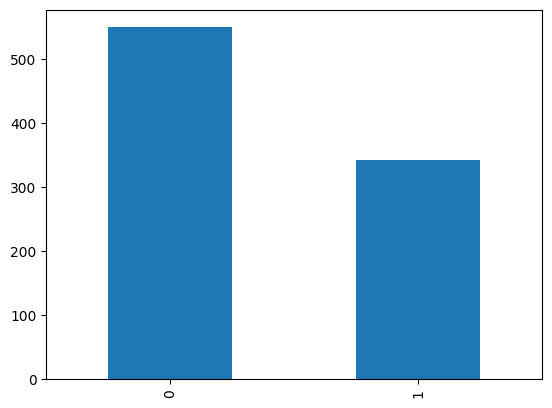

In [20]:
color = 0.5
df['Survived'].value_counts().plot(kind = 'bar')

In [21]:
df_proc = df.copy()

In [22]:
df['Age'].info()

<class 'pandas.core.series.Series'>
Int64Index: 891 entries, 803 to 888
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
714 non-null    float64
dtypes: float64(1)
memory usage: 13.9 KB


In [23]:
age_median = df_proc['Age'].median()
df_proc['Age'].fillna(age_median, inplace=True)

In [24]:
df_proc.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 803 to 888
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.5+ KB


In [25]:
# for binary category encoding: label encoding

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
df_proc['Sex_Encoded'] = LabelEncoder().fit_transform(df_proc['Sex'])
print(df_proc[['Sex', 'Sex_Encoded']].tail())

        Sex  Sex_Encoded
859    male            1
863  female            0
868    male            1
878    male            1
888  female            0


In [26]:
df_proc.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Sex_Encoded      int64
dtype: object

In [27]:
numerical_features = ['Age']
df_proc[numerical_features].describe()

,Age
count,891.000000
mean,29.361582
std,13.019697
min,0.420000
25%,22.000000
50%,28.000000
75%,35.000000
max,80.000000


In [28]:
# Z-score standardization

df_proc[['Age_Standardized']] = StandardScaler().fit_transform(df_proc[['Age']])
print (df_proc[df_proc['Age'] == 80])

     PassengerId  Survived  Pclass                                  Name  \
630          631         1       1  Barkworth, Mr. Algernon Henry Wilson   

      Sex   Age  SibSp  Parch Ticket  Fare Cabin Embarked  Sex_Encoded  \
630  male  80.0      0      0  27042  30.0   A23        S            1   

     Age_Standardized  
630          3.891554  


In [29]:
# Average Normalization

df_proc[['Age_Normalized']] = MinMaxScaler().fit_transform(df_proc[['Age']])
print (df_proc.tail())

     PassengerId  Survived  Pclass                                      Name  \
859          860         0       3                          Razi, Mr. Raihed   
863          864         0       3         Sage, Miss. Dorothy Edith "Dolly"   
868          869         0       3               van Melkebeke, Mr. Philemon   
878          879         0       3                        Laleff, Mr. Kristo   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   

        Sex   Age  SibSp  Parch      Ticket     Fare Cabin Embarked  \
859    male  28.0      0      0        2629   7.2292   NaN        C   
863  female  28.0      8      2    CA. 2343  69.5500   NaN        S   
868    male  28.0      0      0      345777   9.5000   NaN        S   
878    male  28.0      0      0      349217   7.8958   NaN        S   
888  female  28.0      1      2  W./C. 6607  23.4500   NaN        S   

     Sex_Encoded  Age_Standardized  Age_Normalized  
859            1         -0.104637     

In [30]:
print(df_proc[['Age_Standardized','Age_Normalized']].describe())

       Age_Standardized  Age_Normalized
count      8.910000e+02      891.000000
mean       1.913920e-16        0.363679
std        1.000562e+00        0.163605
min       -2.224156e+00        0.000000
25%       -5.657365e-01        0.271174
50%       -1.046374e-01        0.346569
75%        4.333115e-01        0.434531
max        3.891554e+00        1.000000


In [31]:
df_proc.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 803 to 888
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PassengerId       891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   Pclass            891 non-null    int64  
 3   Name              891 non-null    object 
 4   Sex               891 non-null    object 
 5   Age               891 non-null    float64
 6   SibSp             891 non-null    int64  
 7   Parch             891 non-null    int64  
 8   Ticket            891 non-null    object 
 9   Fare              891 non-null    float64
 10  Cabin             204 non-null    object 
 11  Embarked          889 non-null    object 
 12  Sex_Encoded       891 non-null    int64  
 13  Age_Standardized  891 non-null    float64
 14  Age_Normalized    891 non-null    float64
dtypes: float64(4), int64(6), object(5)
memory usage: 111.4+ KB


In [32]:
# data overview

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# global style settings
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120  # Sharper figures in the notebook

# basic dimensions 
print("=" * 55)
print("  DATASET DIMENSIONS")
print("=" * 55)
# .shape returns a tuple (number_of_rows, number_of_columns)
print(f"  Rows    : {df_proc.shape[0]}")
print(f"  Columns : {df_proc.shape[1]}")
print()

# data types and non null counts
print("=" * 55)
print("data types + non-null counts")
print("=" * 55)
df_proc.info()
print()

# summary statistics
print("=" * 55)
print("  summary (numerical columns)")
print("=" * 55)
display(df_proc.describe().T.style.background_gradient(cmap="Blues").format(precision=2))

# missing value report
print()
print("=" * 55)
print("  missing value report")
print("=" * 55)

# missing value in columns
missing_count = df_proc.isnull().sum()

# missing value in columns (percentage)
missing_pct = (missing_count / len(df)) * 100

# show
missing_report = pd.DataFrame({
    "Missing Count"  : missing_count,
    "Missing (%)"    : missing_pct.round(2)
})

# show columns with missing values
missing_report = (
    missing_report[missing_report["Missing Count"] > 0]
    .sort_values("Missing (%)", ascending=False)
)

if missing_report.empty:
    print("  No missing values found — great!")
else:
    # highlight: darker = more missing value
    display(
        missing_report.style
        .background_gradient(cmap="Reds", subset=["Missing (%)"])
        .format({"Missing (%)": "{:.2f}%"})
    )

  DATASET DIMENSIONS
  Rows    : 891
  Columns : 15

data types + non-null counts
<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 803 to 888
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PassengerId       891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   Pclass            891 non-null    int64  
 3   Name              891 non-null    object 
 4   Sex               891 non-null    object 
 5   Age               891 non-null    float64
 6   SibSp             891 non-null    int64  
 7   Parch             891 non-null    int64  
 8   Ticket            891 non-null    object 
 9   Fare              891 non-null    float64
 10  Cabin             204 non-null    object 
 11  Embarked          889 non-null    object 
 12  Sex_Encoded       891 non-null    int64  
 13  Age_Standardized  891 non-null    float64
 14  Age_Normalized    891 non-null    float64
dtypes: floa

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.00,446.00,257.35,1.00,223.50,446.00,668.50,891.00
Survived,891.00,0.38,0.49,0.00,0.00,0.00,1.00,1.00
Pclass,891.00,2.31,0.84,1.00,2.00,3.00,3.00,3.00
Age,891.00,29.36,13.02,0.42,22.00,28.00,35.00,80.00
SibSp,891.00,0.52,1.10,0.00,0.00,0.00,1.00,8.00
Parch,891.00,0.38,0.81,0.00,0.00,0.00,0.00,6.00
Fare,891.00,32.20,49.69,0.00,7.91,14.45,31.00,512.33
Sex_Encoded,891.00,0.65,0.48,0.00,0.00,1.00,1.00,1.00
Age_Standardized,891.00,0.00,1.00,-2.22,-0.57,-0.10,0.43,3.89
Age_Normalized,891.00,0.36,0.16,0.00,0.27,0.35,0.43,1.00



  missing value report


,Missing Count,Missing (%)
Cabin,687,77.10%
Embarked,2,0.22%


Test Accuracy: 0.8268


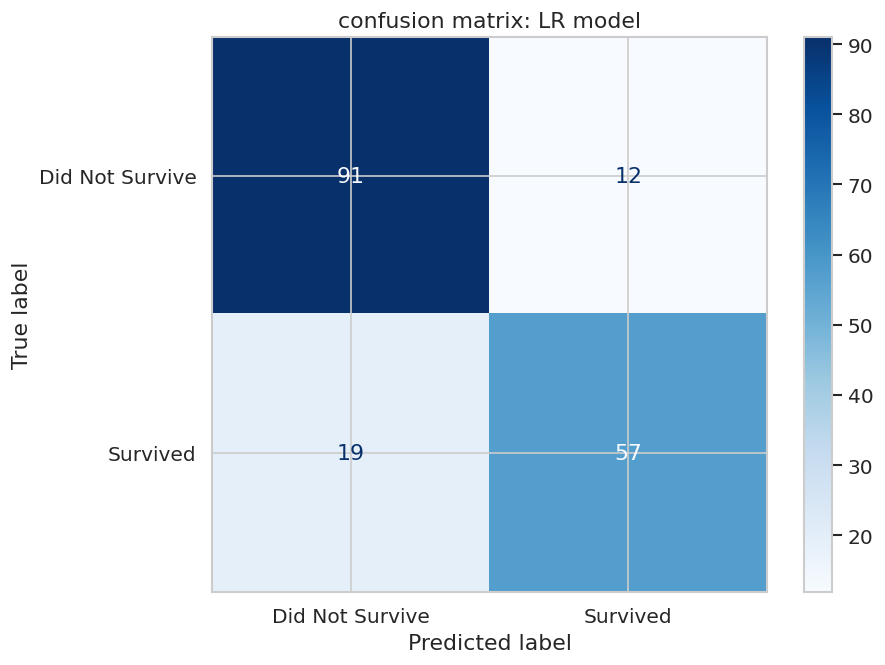

In [33]:

# data preparation and logistic regression 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# define X (training feature) and y (target)
X = df_proc[['Pclass', 'Sex_Encoded', 'Age_Normalized', 'Fare', 'SibSp', 'Parch']]
y = df_proc['Survived'] 

# data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# init logistic regression classifier
log_reg = LogisticRegression(max_iter=200)  # Increase max_iter if convergence warnings arise
log_reg.fit(X_train, y_train)  # Train the model

# model evaluation with accuracy
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# show
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('confusion matrix: LR model')
plt.show()

Test Accuracy (Decision Tree): 0.8380
Comparison with Logistic Regression: 0.8268 (Logistic Regression accuracy)


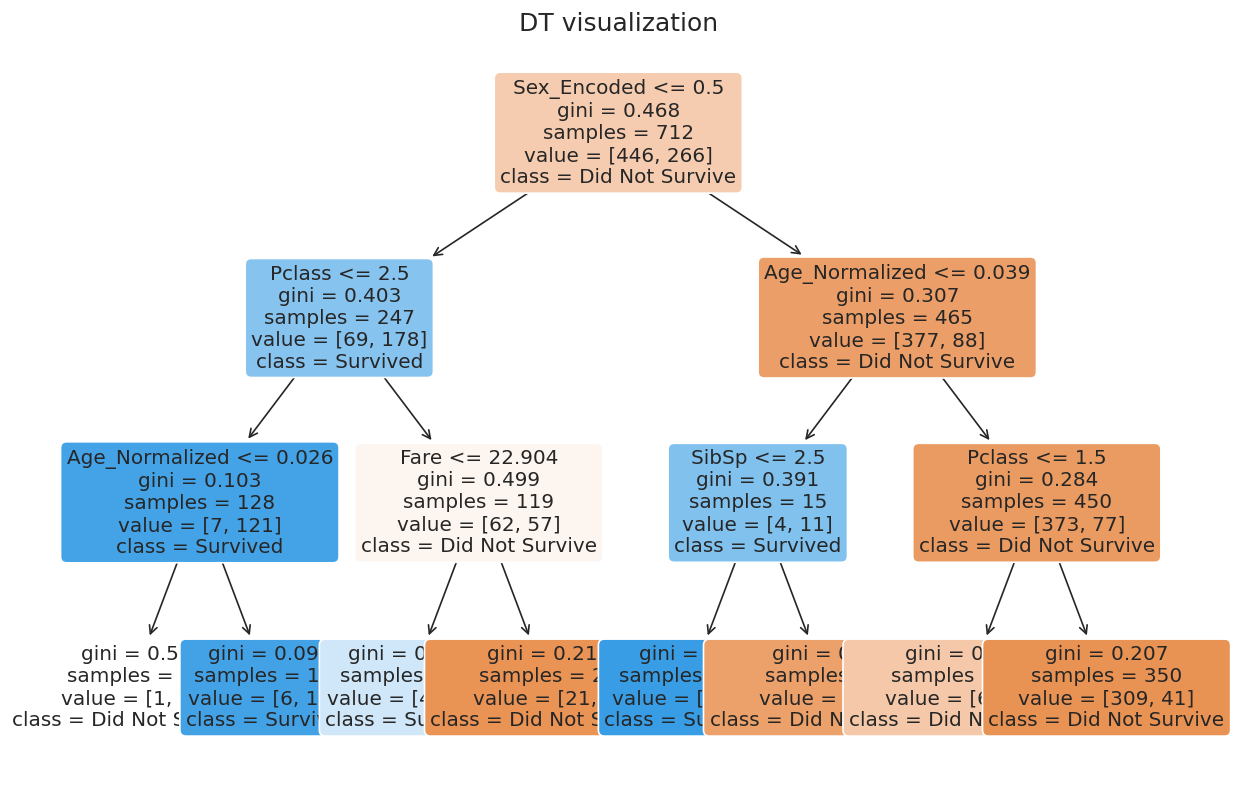

In [34]:
# decision tree classifier

from sklearn.tree import DecisionTreeClassifier, plot_tree

# init decision tree
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)  # Train the Decision Tree model

# DT evaluation
y_pred_tree = tree_clf.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(f"Test Accuracy (Decision Tree): {accuracy_tree:.4f}")  # Display the accuracy
print(f"Comparison with Logistic Regression: {accuracy:.4f} (Logistic Regression accuracy)")

# showed
plt.figure(figsize=(12, 8))
plot_tree(tree_clf, 
          feature_names=X.columns, 
          class_names=['Did Not Survive', 'Survived'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("DT visualization", fontsize=15)
plt.show()


Test Accuracy (Random Forest): 0.8436

Classification Report (Random Forest):
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.88      0.87       103
       Survived       0.83      0.79      0.81        76

       accuracy                           0.84       179
      macro avg       0.84      0.84      0.84       179
   weighted avg       0.84      0.84      0.84       179



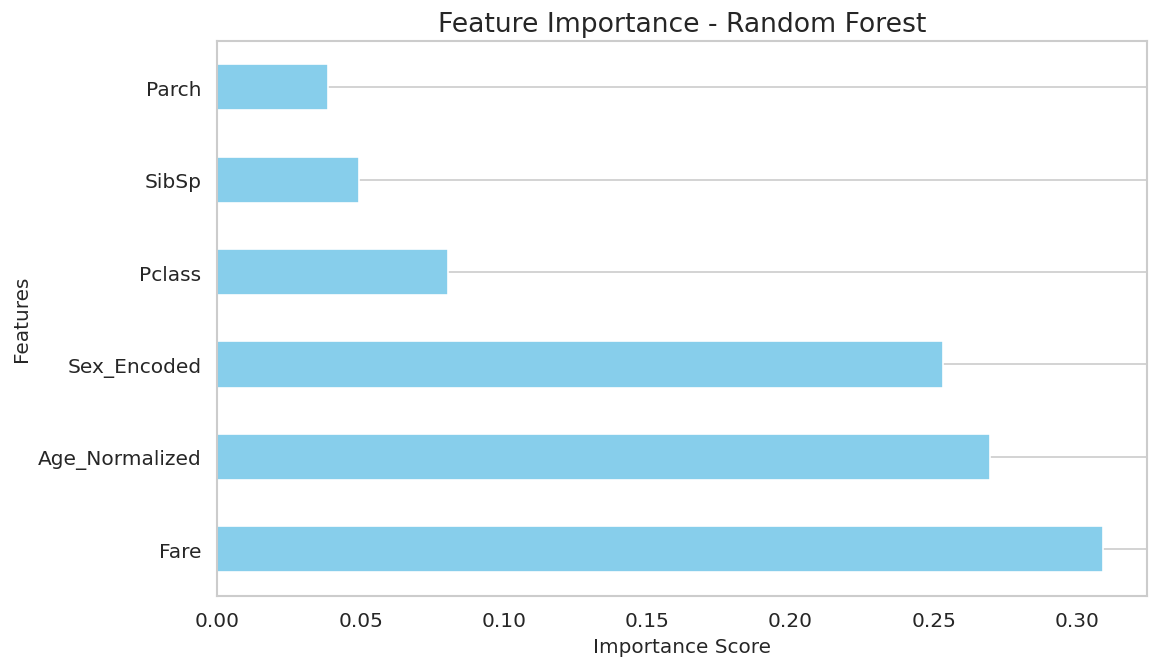

In [35]:
# random forest classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# init random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # Train the Random Forest model

# model evaluation
y_pred_rf = rf_model.predict(X_test)

# show accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Test Accuracy (Random Forest): {accuracy_rf:.4f}")  # Display accuracy

# classification report
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['Did Not Survive', 'Survived']))

# feature importance extraction
feature_importances = rf_model.feature_importances_
feature_names = X_train.columns

# data processing for sorting and plotting
importance_series = pd.Series(feature_importances, index=feature_names)
importance_sorted = importance_series.sort_values(ascending=False)

# show the importance of features
plt.figure(figsize=(10, 6))
importance_sorted.plot(kind='barh', color='skyblue')
plt.title("Feature Importance - Random Forest", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x')
plt.show()

In [36]:
# extreme gradient boosting (XGBoost) 

import sys

# hidden cuda or GPU element
# install but not used would cause IDE crashed
sys.modules['cuda'] = None
sys.modules['cuda._cuda'] = None
sys.modules['cuda._cuda.ccuda'] = None

from xgboost import XGBClassifier

# build XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    tree_method='hist'
)

# training model
xgb_model.fit(X_train, y_train)

# model evaluation
y_pred_xgb = xgb_model.predict(X_test)

# show accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Test Accuracy (XGBoost): {accuracy_xgb:.4f}")  # Display accuracy

# model comparison: LR, DT, RF, XGB
print("\n--- Model Performance Comparison ---")
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Decision Tree Accuracy: {accuracy_tree:.4f}")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")


Test Accuracy (XGBoost): 0.8547

--- Model Performance Comparison ---
Logistic Regression Accuracy: 0.8268
Decision Tree Accuracy: 0.8380
Random Forest Accuracy: 0.8436
XGBoost Accuracy: 0.8547


/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


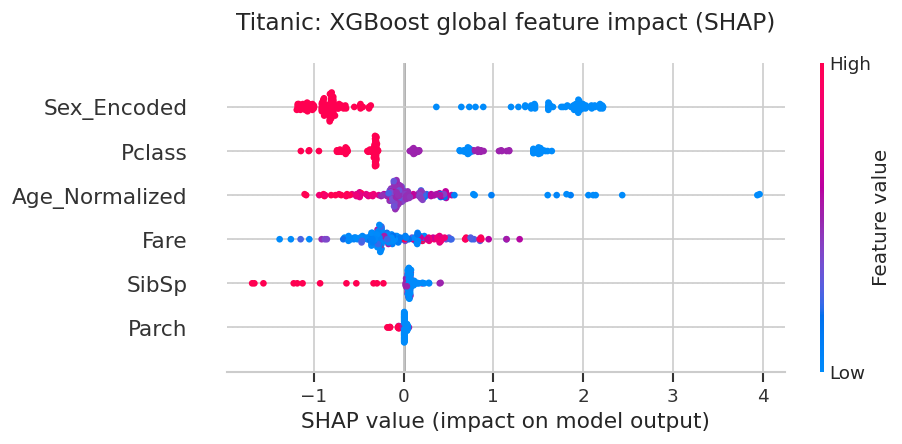

data of the passenger:
Pclass            3.000000
Sex_Encoded       1.000000
Age_Normalized    0.880623
Fare              7.750000
SibSp             0.000000
Parch             0.000000
Name: 116, dtype: float64


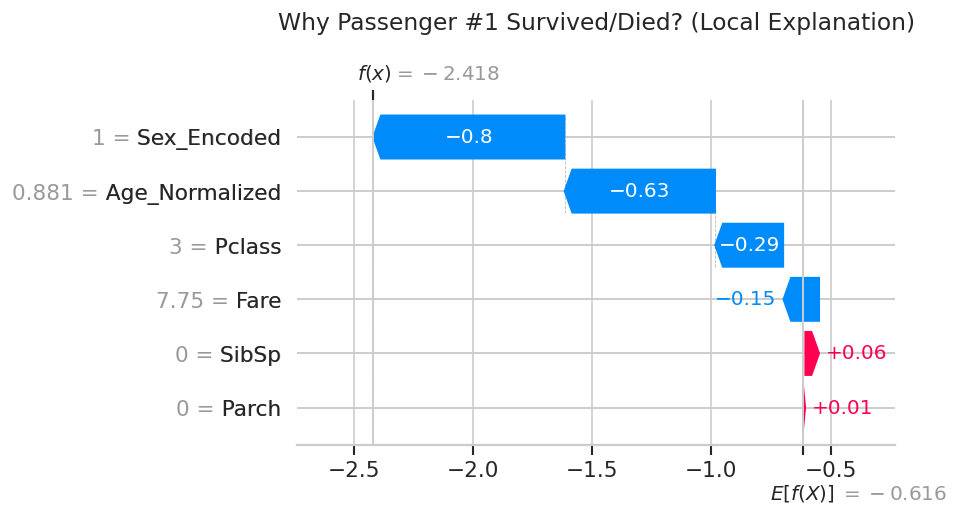

In [37]:
import matplotlib.pyplot as plt
import shap

# init shap explainer for tree-like model, eg DT, RF, XGBoost
explainer = shap.TreeExplainer(xgb_model)

# calculate shap value with X_test
shap_values = explainer(X_test)

# show global explanation plot

plt.figure(figsize=(10, 6))
# show importance and its direction
shap.plots.beeswarm(shap_values, max_display=10, show=False)

plt.title("Titanic: XGBoost global feature impact (SHAP)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# y-axis: importance from high to low
# x-axis: impact direction from negative (left) to positive (right)


# randomly pick a passenger to make sure the explanation
passenger_index = 0
passenger_data = X_test.iloc[passenger_index]

print("data of the passenger:")
print(passenger_data)

# show the prediction from basis to final
plt.figure(figsize=(10, 5))

shap.plots.waterfall(shap_values[passenger_index], show=False)

plt.title(f"Why Passenger #{passenger_index+1} Survived/Died? (Local Explanation)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [39]:
!git --version

git version 2.25.1


In [41]:
!git init

Reinitialized existing Git repository in /mlsteam/lab/.git/


In [42]:
!git add .

hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> AI_Computer_Center_Titanic
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached AI_Computer_Center_Titanic
hint: 
hint: See "git help submodule" for more information.


In [43]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   .ipynb_checkpoints/MNIST-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Titanic-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Titanic_lecturing-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Untitled-checkpoint.ipynb
	new file:   .ipynb_checkpoints/train-checkpoint.py
	new file:   .ipynb_checkpoints/train_tutorial-checkpoint.ipynb
	new file:   AI_Computer_Center_Titanic
	new file:   BUILD
	new file:   MNIST.ipynb
	new file:   Titanic.ipynb
	new file:   Titanic_lecturing.ipynb
	new file:   Untitled.ipynb
	new file:   data/iris.csv
	new file:   datasets/coco128/images/train2017/.ipynb_checkpoints/000000000009-checkpoint.jpg
	new file:   datasets/coco128/images/train2017/.ipynb_checkpoints/000000000025-checkpoint.jpg
	modified:   docker/Dockerfile
	new file:   mimic-code
	modified:   train_tutorial.ipynb
	new file:   tree.dot

Chang

In [44]:
!git commit 'modified AI_Computer_Center_Titanic'

error: pathspec 'modified AI_Computer_Center_Titanic' did not match any file(s) known to git


In [45]:
!git push

remote: Invalid username or token. Password authentication is not supported for Git operations.
fatal: Authentication failed for 'https://github.com/myelintek/yolov9/'


In [46]:
!git config --global user.name "Aaron HYM"
!git config --global user.email 'hyma128@pu.edu.tw'

In [47]:
!git add .

In [48]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   .ipynb_checkpoints/MNIST-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Titanic-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Titanic_lecturing-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Untitled-checkpoint.ipynb
	new file:   .ipynb_checkpoints/train-checkpoint.py
	new file:   .ipynb_checkpoints/train_tutorial-checkpoint.ipynb
	new file:   AI_Computer_Center_Titanic
	new file:   BUILD
	new file:   MNIST.ipynb
	new file:   Titanic.ipynb
	new file:   Titanic_lecturing.ipynb
	new file:   Untitled.ipynb
	new file:   data/iris.csv
	new file:   datasets/coco128/images/train2017/.ipynb_checkpoints/000000000009-checkpoint.jpg
	new file:   datasets/coco128/images/train2017/.ipynb_checkpoints/000000000025-checkpoint.jpg
	modified:   docker/Dockerfile
	new file:   mimic-code
	modified:   train_tutorial.ipynb
	new file:   tree.dot

Chang

In [49]:
!git commit -m 'modified Titanic code'

[main b4c1afa] modified Titanic code
 19 files changed, 5938 insertions(+), 5 deletions(-)
 create mode 100644 .ipynb_checkpoints/MNIST-checkpoint.ipynb
 create mode 100644 .ipynb_checkpoints/Titanic-checkpoint.ipynb
 create mode 100644 .ipynb_checkpoints/Titanic_lecturing-checkpoint.ipynb
 create mode 100644 .ipynb_checkpoints/Untitled-checkpoint.ipynb
 create mode 100644 .ipynb_checkpoints/train-checkpoint.py
 create mode 100644 .ipynb_checkpoints/train_tutorial-checkpoint.ipynb
 create mode 160000 AI_Computer_Center_Titanic
 create mode 100644 BUILD
 create mode 100644 MNIST.ipynb
 create mode 100644 Titanic.ipynb
 create mode 100644 Titanic_lecturing.ipynb
 create mode 100644 Untitled.ipynb
 create mode 100644 data/iris.csv
 create mode 100644 datasets/coco128/images/train2017/.ipynb_checkpoints/000000000009-checkpoint.jpg
 create mode 100644 datasets/coco128/images/train2017/.ipynb_checkpoints/000000000025-checkpoint.jpg
 create mode 160000 mimic-code
 create mode 100644 tree.dot


In [52]:
!git remote rename origin upstream

In [53]:
!git remote add origin https://github.com/zaoa3345678-arch/AI_Computer_Center_Titanic

In [ ]:
!git push origin main 